In [ ]:
# ===============================
# 1. Імпорт необхідних бібліотек
# ===============================

import os
import sys
import random
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from torchvision.models import ResNet18_Weights



# Фіксація випадкових значень для відтворюваності результатів
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# Перевірка доступності апаратного прискорювача
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cuda


In [29]:
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA у PyTorch:", torch.version.cuda)
print("CUDA доступна:", torch.cuda.is_available())
print("Кількість GPU:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Використовується пристрій:", device)

Python: g:\GOIT\GitHub\goit-dlcv-hw06\.venv-gpu\Scripts\python.exe
PyTorch: 2.14.0+cu126
CUDA у PyTorch: 12.6
CUDA доступна: True
Кількість GPU: 1
GPU: NVIDIA GeForce GTX 1070 Ti
Використовується пристрій: cuda


In [ ]:
# =================================================================================================================
# 2. Визначення шляхів до папок з урахуванням структури у каталозі datasets та завантаження даних через ImageFolder
# =================================================================================================================

base_train = os.path.join('datasets', 'seg_train')
base_test = os.path.join('datasets', 'seg_test')

# Перевірка наявності вкладеної папки seg_train/seg_train (якщо розпаковано з підпапкою)
train_dir = os.path.join(base_train, 'seg_train') if os.path.exists(os.path.join(base_train, 'seg_train')) else base_train
test_dir = os.path.join(base_test, 'seg_test') if os.path.exists(os.path.join(base_test, 'seg_test')) else base_test

print(f"Шлях до тренувальних даних: {train_dir}")
print(f"Шлях до тестових даних:      {test_dir}")

# 2. Визначення трансформацій
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Завантаження датасетів через ImageFolder
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_base_dataset = datasets.ImageFolder(root=train_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

# Стратифіковане розбиття тренувальних даних на Train (80%) та Validation (20%)
targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    list(range(len(targets))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(val_base_dataset, val_idx)

# Створення DataLoader (для CPU залишаємо num_workers=0)
batch_size = 32

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# 5. Вивід інформації про вибірки та батчі
class_names = full_train_dataset.classes
print(f"\nКількість класів: {len(class_names)}")
print(f"Класи: {class_names}")
print(f"Тренувальна вибірка: {len(train_subset)} зображень")
print(f"Валідаційна вибірка:  {len(val_subset)} зображень")
print(f"Тестова вибірка:       {len(test_dataset)} зображень")

images, labels = next(iter(train_loader))
print(f"\nФорма батчу зображень: {images.shape}")
print(f"Форма батчу міток:     {labels.shape}")

Шлях до тренувальних даних: datasets\seg_train\seg_train
Шлях до тестових даних:      datasets\seg_test\seg_test

Кількість класів: 6
Класи: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Тренувальна вибірка: 11227 зображень
Валідаційна вибірка:  2807 зображень
Тестова вибірка:       3000 зображень

Форма батчу зображень: torch.Size([32, 3, 150, 150])
Форма батчу міток:     torch.Size([32])


In [ ]:
# =================================
# 4. Визначення простої CNN моделі
# =================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Блок 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Блок 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Автоматичне зменшення до 1 × 1
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(num_classes=len(class_names)).to(device)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Line

In [ ]:
# ==================================================
# 5. Перевірка форми виходу моделі для одного батчу
# ==================================================

images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print(f"Форма вхідного батчу:  {images.shape}")
print(f"Форма виходу моделі:   {outputs.shape}")

Форма вхідного батчу:  torch.Size([32, 3, 150, 150])
Форма виходу моделі:   torch.Size([32, 6])


In [ ]:
# ======================================================================
# 6. Визначення функції втрат, оптимізатора та інших параметрів навчання
# ======================================================================

criterion = nn.CrossEntropyLoss()

# Оптимізатор Adam
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Автоматичне зменшення learning rate,
# якщо validation loss перестає покращуватися
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# Основні параметри майбутнього навчання
num_epochs = 10
best_val_loss = float('inf')
best_model_weights = None

print(f"Функція втрат: {criterion}")
print(f"Оптимізатор: {optimizer}")
print(f"Початковий learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Кількість епох: {num_epochs}")

Функція втрат: CrossEntropyLoss()
Оптимізатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Початковий learning rate: 0.001
Кількість епох: 10


In [34]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print(f"Форма outputs: {outputs.shape}")
print(f"Форма labels:  {labels.shape}")
print(f"Початкове значення loss: {loss.item():.4f}")

Форма outputs: torch.Size([32, 6])
Форма labels:  torch.Size([32])
Початкове значення loss: 1.8612


In [ ]:
# ==========================================================
# 7. Функції для навчання та валідації протягом однієї епохи
# ==========================================================


def train_one_epoch(model, loader, criterion, optimizer, device):
    
    # Навчання моделі протягом однієї епохи.

    # Параметри:
    #     model (nn.Module): модель для навчання;
    #     loader (DataLoader): завантажувач даних;
    #     criterion (nn.Module): функція втрат;
    #     optimizer (optim.Optimizer): оптимізатор;
    #     device (torch.device): пристрій для обчислень.
    #
    # Повертає:
    #     epoch_loss       — середнє значення функції втрат;
    #     epoch_accuracy   — точність;
    #     epoch_f1_macro   — F1-score macro;
    #     epoch_f1_weighted — F1-score weighted.
    

    model.train()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Очищення градієнтів попереднього кроку
        optimizer.zero_grad(set_to_none=True)

        # Пряме поширення
        outputs = model(images)

        # Обчислення втрат
        loss = criterion(outputs, labels)

        # Зворотне поширення
        loss.backward()

        # Оновлення ваг моделі
        optimizer.step()

        # Накопичення втрат
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        # Отримання прогнозованих класів
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    # Середня втрата за всю епоху
    epoch_loss = running_loss / total_samples

    # Перетворення списків у масиви NumPy
    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    # Accuracy
    epoch_accuracy = np.mean(all_labels == all_predictions)

    # F1-score для багатокласової класифікації
    epoch_f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    epoch_f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1_macro,
        epoch_f1_weighted
    )



# Валідація моделі протягом однієї епохи

def validate_one_epoch(model, loader, criterion, device):
    
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    # Градієнти під час валідації не потрібні
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Пряме поширення
            outputs = model(images)

            # Обчислення втрат
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            # Отримання прогнозованих класів
            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    # Середня втрата за всю валідаційну вибірку
    epoch_loss = running_loss / total_samples

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    # Accuracy
    epoch_accuracy = np.mean(all_labels == all_predictions)

    # F1-score macro
    epoch_f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    # F1-score weighted
    epoch_f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1_macro,
        epoch_f1_weighted
    )

# Основний цикл навчання та валідації

# Історія навчання
history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1_macro': [],
    'train_f1_weighted': [],

    'val_loss': [],
    'val_accuracy': [],
    'val_f1_macro': [],
    'val_f1_weighted': []
}


# Параметри навчання
num_epochs = 10
best_val_f1 = -float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

start_time = time.time()


for epoch in range(num_epochs):
    epoch_start_time = time.time()

    # Навчання
    train_loss, train_accuracy, train_f1_macro, train_f1_weighted = (
        train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )
    )

    # Валідація
    val_loss, val_accuracy, val_f1_macro, val_f1_weighted = (
        validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )
    )

    # Передаємо validation loss до планувальника
    scheduler.step(val_loss)

    # Збереження історії
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['train_f1_macro'].append(train_f1_macro)
    history['train_f1_weighted'].append(train_f1_weighted)

    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1_macro'].append(val_f1_macro)
    history['val_f1_weighted'].append(val_f1_weighted)

    # Зберігаємо модель з найкращим validation F1
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(
            best_model_weights,
            'best_simple_cnn_by_f1.pth'
        )
        best_marker = ' ← найкраща модель за F1'
    else:
        best_marker = ''

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time

    print(
        f"Епоха [{epoch + 1}/{num_epochs}] | "
        f"Час: {epoch_time:.1f} с | "
        f"LR: {current_lr:.6f}"
    )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Train F1-macro: {train_f1_macro:.4f} | "
        f"Train F1-weighted: {train_f1_weighted:.4f}"
    )

    print(
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val F1-macro: {val_f1_macro:.4f} | "
        f"Val F1-weighted: {val_f1_weighted:.4f}"
        f"{best_marker}\n"
    )


# Завантаження найкращих ваг після завершення навчання
model.load_state_dict(best_model_weights)
model.to(device)

total_time = time.time() - start_time

print(f"Загальний час навчання: {total_time / 60:.2f} хв")
print(f"Найкращий validation F1: {best_val_f1:.4f}")
print("Найкращі ваги моделі завантажено.")

Епоха [1/10] | Час: 28.6 с | LR: 0.001000
Train loss: 1.0684 | Train acc: 0.5726 | Train F1-macro: 0.5683 | Train F1-weighted: 0.5682
Val loss: 0.8638 | Val acc: 0.6505 | Val F1-macro: 0.6373 | Val F1-weighted: 0.6364 ← найкраща модель за F1

Епоха [2/10] | Час: 28.8 с | LR: 0.001000
Train loss: 0.8029 | Train acc: 0.6948 | Train F1-macro: 0.6947 | Train F1-weighted: 0.6942
Val loss: 0.6795 | Val acc: 0.7410 | Val F1-macro: 0.7415 | Val F1-weighted: 0.7406 ← найкраща модель за F1

Епоха [3/10] | Час: 29.7 с | LR: 0.001000
Train loss: 0.7449 | Train acc: 0.7180 | Train F1-macro: 0.7182 | Train F1-weighted: 0.7176
Val loss: 1.0862 | Val acc: 0.6074 | Val F1-macro: 0.5795 | Val F1-weighted: 0.5828

Епоха [4/10] | Час: 30.7 с | LR: 0.001000
Train loss: 0.6971 | Train acc: 0.7418 | Train F1-macro: 0.7422 | Train F1-weighted: 0.7416
Val loss: 0.6908 | Val acc: 0.7592 | Val F1-macro: 0.7603 | Val F1-weighted: 0.7590 ← найкраща модель за F1

Епоха [5/10] | Час: 31.2 с | LR: 0.000500
Train loss

У результаті навчання власної згорткової нейронної мережі на наборі Intel Image Classification найкращі результати на валідаційній вибірці отримано на 8-й епосі. 
Значення accuracy становило 82,15%, F1-macro — 0,8232, а F1-weighted — 0,8217. Отримані показники відповідають очікуваному діапазону для простої CNN, розробленої з нуля. 
Значна різниця між тренуванням на CPU та GPU підтвердила доцільність використання CUDA: повний час навчання скоротився до 4,94 хвилини (на CPU - приблизно 75 хвилин). Ознак сильного перенавчання не виявлено, оскільки тренувальні та валідаційні метрики залишаються близькими. 

In [36]:
model.load_state_dict(best_model_weights)
model.to(device)

print(f"Модель працює на: {next(model.parameters()).device}")

Модель працює на: cuda:0


In [ ]:
# =====================================
# 9. Оцінка моделі на тестовій вибірці
# =====================================


def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / total_samples

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        average_loss,
        accuracy,
        f1_macro,
        f1_weighted,
        all_labels,
        all_predictions
    )

In [ ]:
# =======================================================================
# 10. Завантаження найкращих ваг моделі перед оцінкою на тестовій вибірці
# =======================================================================


model.load_state_dict(best_model_weights)
model.to(device)

(
    test_loss,
    test_accuracy,
    test_f1_macro,
    test_f1_weighted,
    test_labels,
    test_predictions
) = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print("Результати на тестовій вибірці:")
print(f"Test loss:              {test_loss:.4f}")
print(f"Test accuracy:          {test_accuracy:.4f}")
print(f"Test accuracy (%):      {test_accuracy * 100:.2f}%")
print(f"Test F1-score macro:    {test_f1_macro:.4f}")
print(f"Test F1-score weighted: {test_f1_weighted:.4f}")

Результати на тестовій вибірці:
Test loss:              0.4757
Test accuracy:          0.8260
Test accuracy (%):      82.60%
Test F1-score macro:    0.8265
Test F1-score weighted: 0.8255


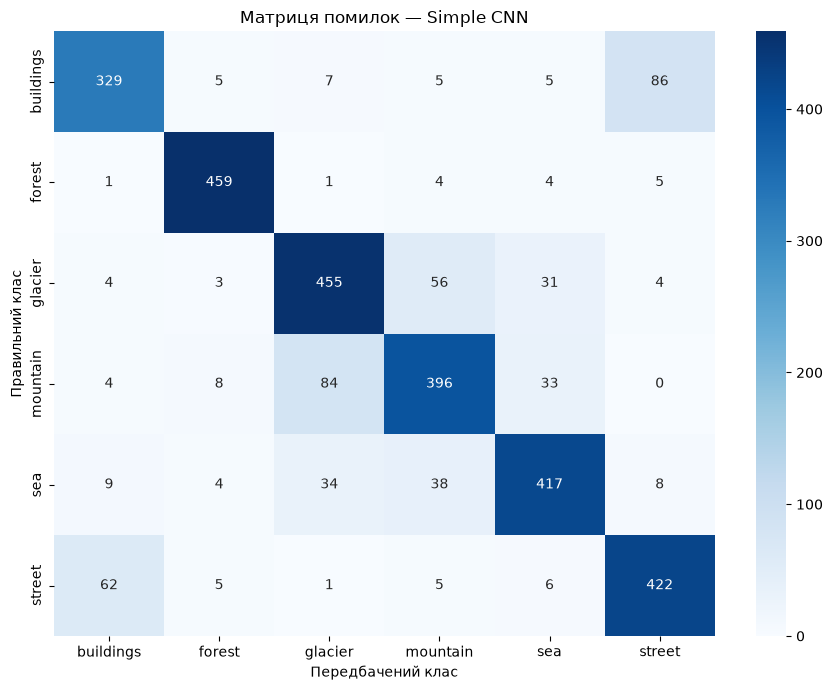

In [ ]:
# Матриця помилок

cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Матриця помилок — Simple CNN')
plt.xlabel('Передбачений клас')
plt.ylabel('Правильний клас')
plt.tight_layout()
plt.show()

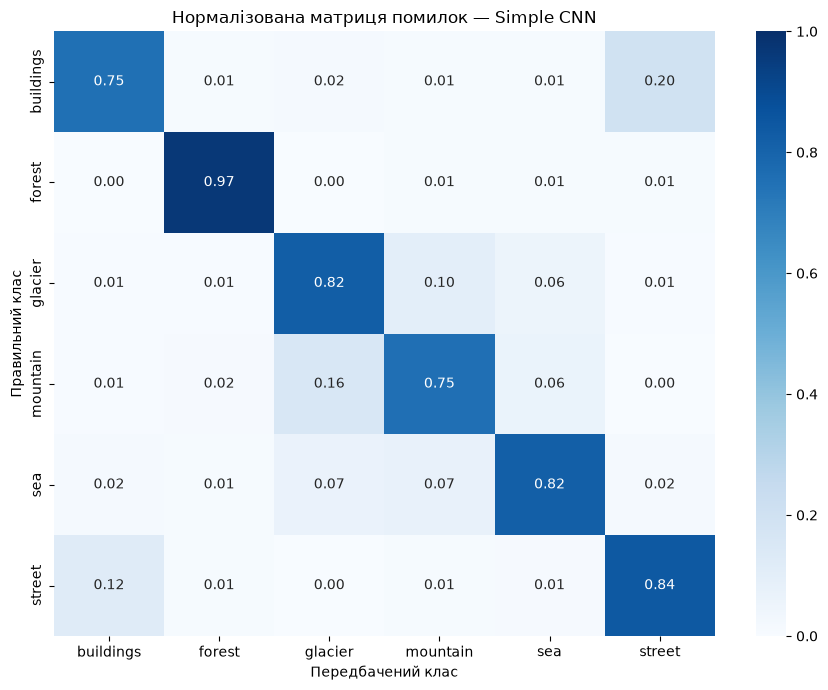

In [41]:
cm_normalized = confusion_matrix(
    test_labels,
    test_predictions,
    normalize='true'
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)

plt.title('Нормалізована матриця помилок — Simple CNN')
plt.xlabel('Передбачений клас')
plt.ylabel('Правильний клас')
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# 11. Обчислення метрик для оцінки моделі
# =========================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / total_samples

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        average_loss,
        accuracy,
        f1_macro,
        f1_weighted,
        all_labels,
        all_predictions
    )


# Завантаження найкращої моделі
model.load_state_dict(best_model_weights)
model.to(device)

print("Пристрій моделі:", next(model.parameters()).device)


# Оцінювання на тестовій вибірці
(
    test_loss,
    test_accuracy,
    test_f1_macro,
    test_f1_weighted,
    test_labels,
    test_predictions
) = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)


# Виведення числових результатів
print("\nРезультати на тестовій вибірці:")
print(f"Test loss:              {test_loss:.4f}")
print(f"Test accuracy:          {test_accuracy:.4f}")
print(f"Test accuracy (%):      {test_accuracy * 100:.2f}%")
print(f"Test F1-score macro:    {test_f1_macro:.4f}")
print(f"Test F1-score weighted: {test_f1_weighted:.4f}")


# Classification report
print("\nClassification report:\n")

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Пристрій моделі: cuda:0

Результати на тестовій вибірці:
Test loss:              0.4757
Test accuracy:          0.8260
Test accuracy (%):      82.60%
Test F1-score macro:    0.8265
Test F1-score weighted: 0.8255

Classification report:

              precision    recall  f1-score   support

   buildings     0.8044    0.7529    0.7778       437
      forest     0.9483    0.9684    0.9582       474
     glacier     0.7818    0.8228    0.8018       553
    mountain     0.7857    0.7543    0.7697       525
         sea     0.8407    0.8176    0.8290       510
      street     0.8038    0.8423    0.8226       501

    accuracy                         0.8260      3000
   macro avg     0.8275    0.8264    0.8265      3000
weighted avg     0.8258    0.8260    0.8255      3000



### Загальні висновки щодо Simple CNN

У межах першого варіанту було розроблено та навчено власну згорткову нейронну мережу для класифікації природних сцен із набору Intel Image Classification. Модель працювала з шістьма класами: buildings, forest, glacier, mountain, sea і street.

Для підготовки даних зображення було приведено до розміру 150 × 150 пікселів, нормалізовано та розділено на навчальну, валідаційну й тестову вибірки. 

Для навчання було використано:

- CrossEntropyLoss як функцію втрат;

- оптимізатор Adam;

- Dropout для зменшення перенавчання;

- ReduceLROnPlateau для автоматичного зменшення швидкості навчання;

- F1-macro як основну метрику вибору найкращої моделі.

**Отримані результати:**

Найкращий результат на валідаційній вибірці отримано на 8-й епосі:

Validation loss:       0.4933<br>
Validation accuracy:   82.15%<br>
Validation F1-macro:   0.8232<br>
Validation F1-weighted: 0.8217

Ці результати відповідають орієнтовним очікуванням для простої CNN, розробленої з нуля:

Очікувана accuracy: 75–85% <br>
Очікуваний F1-score: 0.73–0.83

Отриманий F1-macro = 0.8232 перебуває на верхній межі очікуваного діапазону. Це свідчить про достатньо збалансовану якість класифікації шести класів.

Незначна різниця між F1-macro = 0.8232 і F1-weighted = 0.8217 показує, що модель не має суттєвої переваги лише на окремих класах. Її якість загалом розподілена досить рівномірно.

**Аналіз перенавчання:**

На останній епосі спостерігалися такі результати:

Train accuracy: 80.00% <br>
Validation accuracy: 80.01%<br>
Train F1-macro: 0.8011 <br>
Validation F1-macro: 0.8000

Різниця між навчальними та валідаційними показниками невелика. Отже, сильного перенавчання не виявлено.

Після 8-ї епохи validation F1-score знизився:<br>
Епоха 8: 0.8232 <br>
Епоха 9: 0.7975 <br>
Епоха 10: 0.8000

Тому було правильно зберігати модель із найкращим validation F1-score, а не використовувати ваги останньої епохи.

**Використання GPU**

Після встановлення CUDA навчання стало значно швидшим: <br>
Час однієї епохи: приблизно 28–31 секунда <br>
Загальний час навчання: 4.94 хвилини <br>
Раніше навчання тієї самої моделі на CPU (Intel(R) Core(TM) i3-8100 CPU @ 3.60GHz)займало приблизно 75 хвилин. Використання NVIDIA GeForce GTX 1070 Ti скоротило час навчання приблизно у 15–20 разів, що підтверджує доцільність використання GPU для задач комп’ютерного зору.

**Переваги моделі:**

Розроблена CNN має такі переваги: <br>
проста для розуміння та реалізації; <br>
не потребує попередньо навчаної моделі; <br>
має невелику кількість шарів; <br>
швидко навчається на GPU; <br>
досягає accuracy понад 80%; <br>
демонструє достатньо близькі train і validation показники; <br>
може бути використана як базова модель для порівняння з Transfer Learning.

**Обмеження моделі:**

Попри хороший результат, проста CNN має певні обмеження:<br>
вона навчається лише на цьому конкретному наборі даних; <br>
не використовує ознаки, попередньо вивчені на великих наборах зображень;<br>
може плутати візуально схожі класи, наприклад glacier і mountain; <br>
якість залежить від аугментації та вибраних гіперпараметрів;<br>
на CPU навчання є значно повільнішим; <br>
окремі валідаційні метрики мають помітні коливання між епохами.

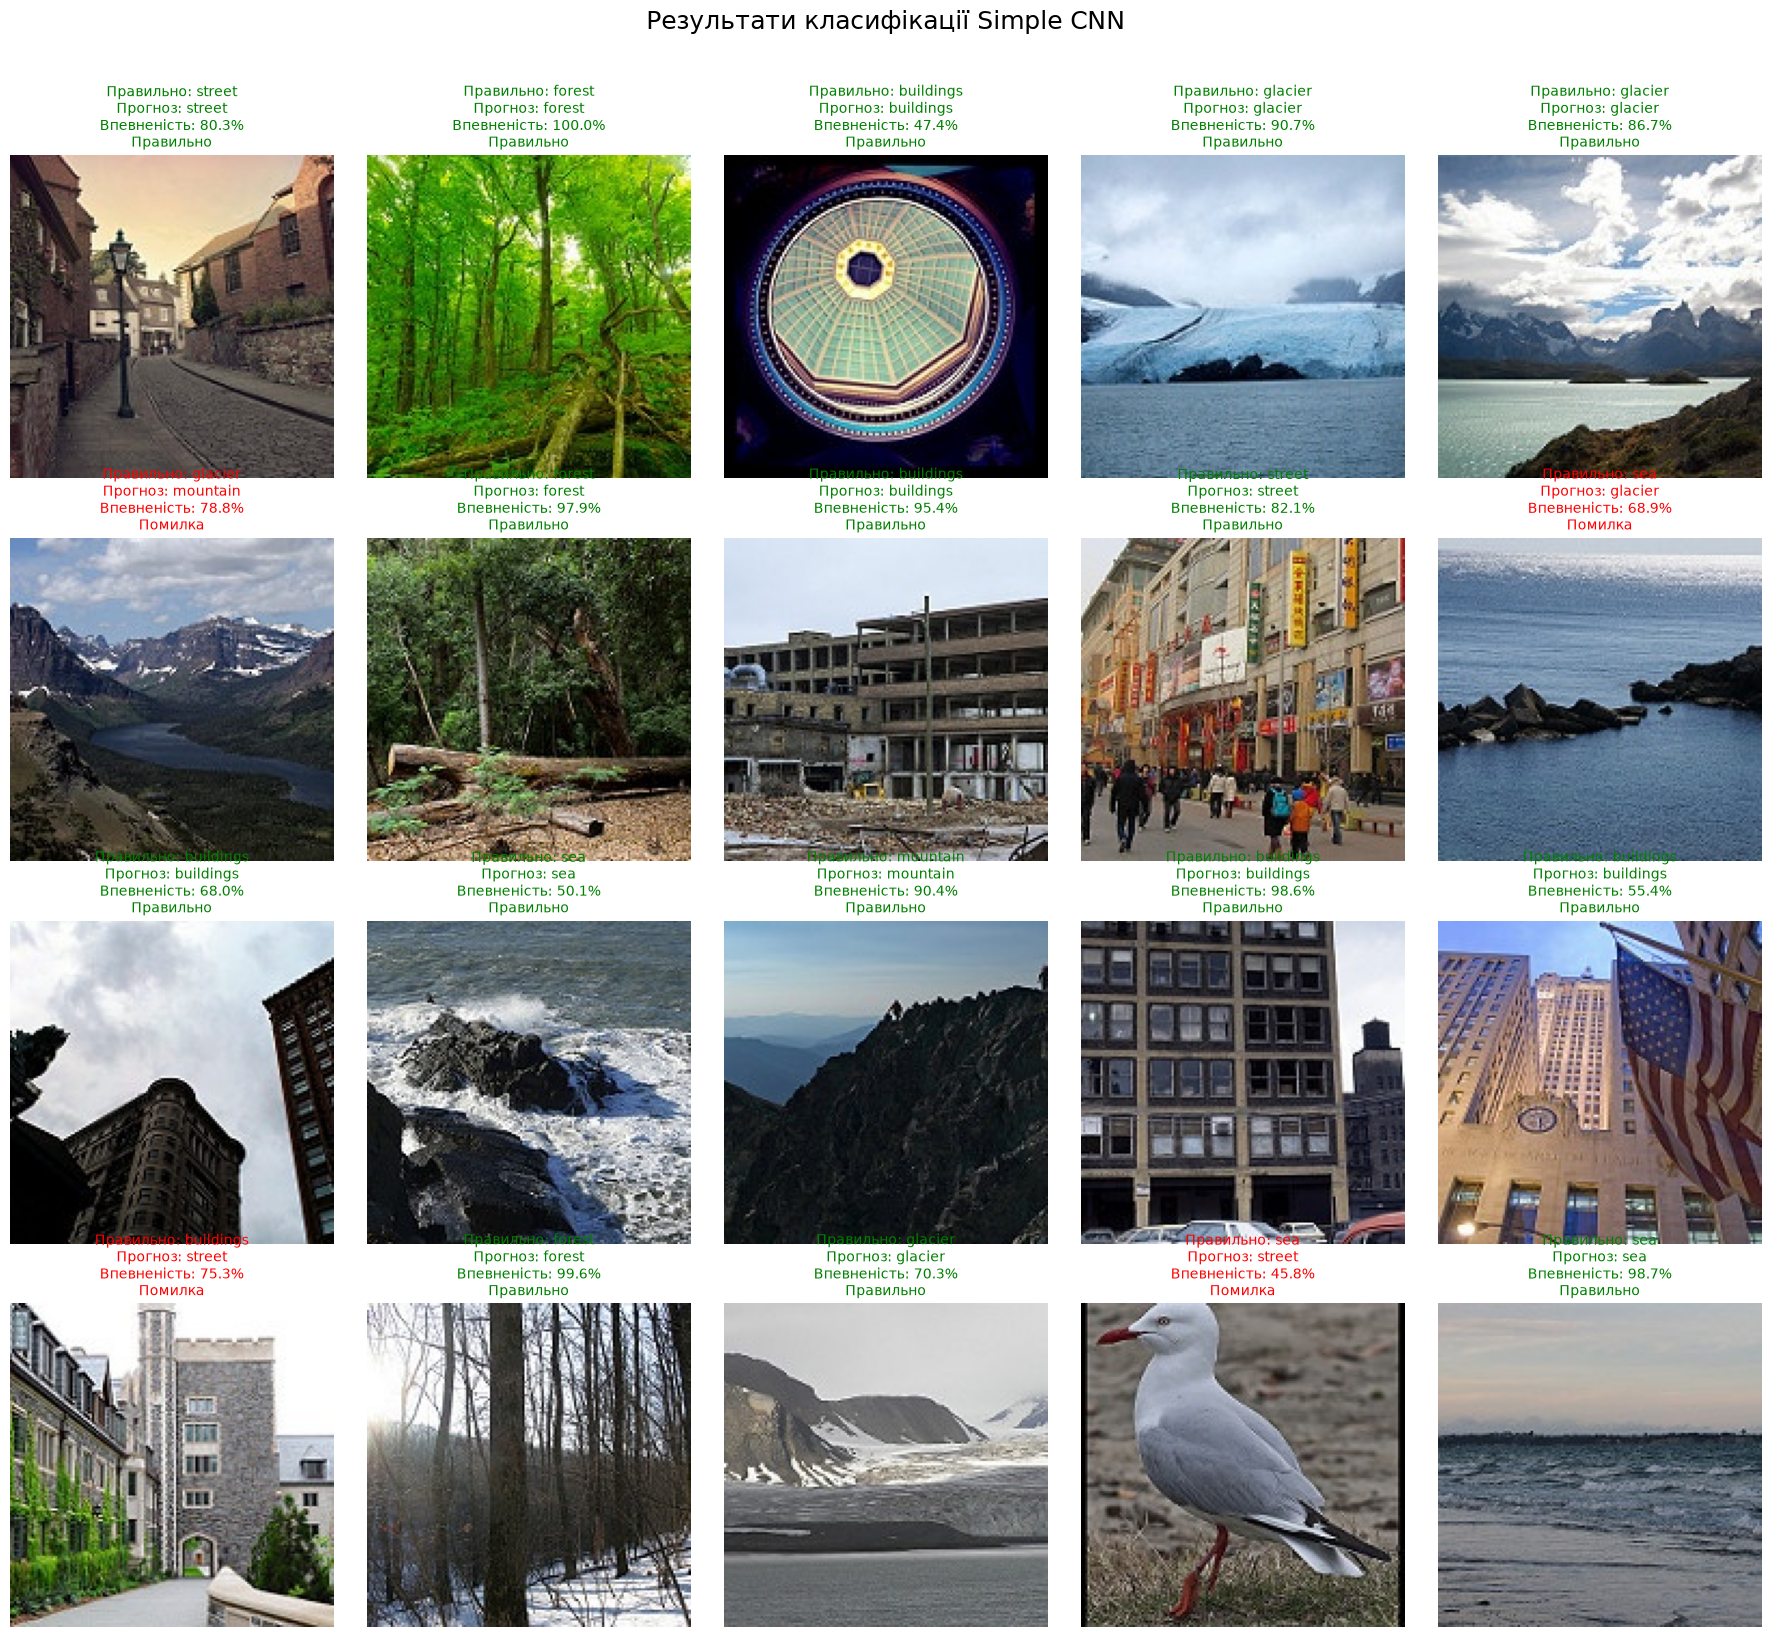

In [ ]:
# =========================================
# 12. Візуалізація результатів класифікації
# =========================================

def denormalize_image(image_tensor, mean, std):
    """
    Повертає зображення з нормалізованого
    Tensor-формату у формат для matplotlib.
    """

    image = image_tensor.clone().cpu()

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    image = image * std + mean
    image = image.permute(1, 2, 0)

    image = torch.clamp(image, 0, 1)

    return image.numpy()


def show_predictions(
    model,
    dataset,
    class_names,
    device,
    num_images=20,
    seed=42
):
    model.eval()

    random.seed(seed)

    num_images = min(num_images, len(dataset))
    selected_indices = random.sample(
        range(len(dataset)),
        num_images
    )

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    columns = 5
    rows = int(np.ceil(num_images / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(18, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    with torch.no_grad():
        for plot_index, dataset_index in enumerate(selected_indices):
            image_tensor, true_label = dataset[dataset_index]

            input_tensor = image_tensor.unsqueeze(0).to(device)

            outputs = model(input_tensor)
            probabilities = torch.softmax(outputs, dim=1)

            confidence, predicted_label = torch.max(
                probabilities,
                dim=1
            )

            predicted_label = predicted_label.item()
            confidence = confidence.item()

            image = denormalize_image(
                image_tensor,
                mean,
                std
            )

            true_class = class_names[true_label]
            predicted_class = class_names[predicted_label]

            if true_label == predicted_label:
                title_color = 'green'
                result_text = 'Правильно'
            else:
                title_color = 'red'
                result_text = 'Помилка'

            axes[plot_index].imshow(image)
            axes[plot_index].set_title(
                f"Правильно: {true_class}\n"
                f"Прогноз: {predicted_class}\n"
                f"Впевненість: {confidence:.1%}\n"
                f"{result_text}",
                color=title_color,
                fontsize=10
            )
            axes[plot_index].axis('off')

    for empty_axis in axes[num_images:]:
        empty_axis.axis('off')

    figure.suptitle(
        'Результати класифікації Simple CNN',
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


show_predictions(
    model=model,
    dataset=test_dataset,
    class_names=class_names,
    device=device,
    num_images=20,
    seed=42
)

### Варіант B: Transfer Learning

Переходимо до другого підходу — використання попередньо навченої моделі ResNet18.

In [ ]:
# ================================
# 13. Нормалізація даних ImageNet
# ================================
    
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

In [ ]:
# ==============================================
# 14. Для тренувальних даних додамо аугментацію
# ==============================================

resnet_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

resnet_val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
# ===================================
# 15. Підготовка даних для ResNet18
# ===================================

# Шляхи до даних
train_dir = r'datasets\seg_train\seg_train'
test_dir = r'datasets\seg_test\seg_test'

# Датасет із трансформаціями для тренування
full_resnet_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=resnet_train_transforms
)

# Окремий датасет для валідації без аугментації
resnet_val_base_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=resnet_val_test_transforms
)

# Тестовий датасет без аугментації
resnet_test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=resnet_val_test_transforms
)

# Стратифікований поділ на train і validation
targets = full_resnet_train_dataset.targets

train_indices, val_indices = train_test_split(
    list(range(len(targets))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

resnet_train_subset = Subset(
    full_resnet_train_dataset,
    train_indices
)

resnet_val_subset = Subset(
    resnet_val_base_dataset,
    val_indices
)

# Для ResNet18 на GPU можна використати batch size 32
resnet_batch_size = 32

resnet_train_loader = DataLoader(
    resnet_train_subset,
    batch_size=resnet_batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

resnet_val_loader = DataLoader(
    resnet_val_subset,
    batch_size=resnet_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=resnet_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

resnet_class_names = full_resnet_train_dataset.classes

print(f"Класи: {resnet_class_names}")
print(f"Тренувальна вибірка: {len(resnet_train_subset)}")
print(f"Валідаційна вибірка: {len(resnet_val_subset)}")
print(f"Тестова вибірка: {len(resnet_test_dataset)}")

images, labels = next(iter(resnet_train_loader))

print(f"Форма батчу: {images.shape}")
print(f"Форма міток: {labels.shape}")

Класи: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Тренувальна вибірка: 11227
Валідаційна вибірка: 2807
Тестова вибірка: 3000
Форма батчу: torch.Size([32, 3, 224, 224])
Форма міток: torch.Size([32])


In [ ]:
# ====================================================
# Завантаження ResNet18 із попередньо навченими вагами
# ====================================================


resnet_model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# Заморожуємо всі попередні шари
for parameter in resnet_model.parameters():
    parameter.requires_grad = False

# Кількість входів фінального шару
num_features = resnet_model.fc.in_features

# Новий класифікатор для 6 класів
resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(128, len(resnet_class_names))
)

# Переміщення моделі на GPU або CPU
resnet_model = resnet_model.to(device)

print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\eugen/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# ==============================================
# 16. Підрахунок кількості параметрів у ResNet18
# ==============================================


total_parameters = sum(
    parameter.numel()
    for parameter in resnet_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in resnet_model.parameters()
    if parameter.requires_grad
)

print(f"Усього параметрів: {total_parameters:,}")
print(f"Параметрів для навчання: {trainable_parameters:,}")

Усього параметрів: 11,242,950
Параметрів для навчання: 66,438


In [ ]:
# ====================================================
# 17. Перевірка форми виходу ResNet18 для одного батчу
# ====================================================

images, labels = next(iter(resnet_train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = resnet_model(images)

print(f"Форма входу:  {images.shape}")
print(f"Форма виходу: {outputs.shape}")

Форма входу:  torch.Size([32, 3, 224, 224])
Форма виходу: torch.Size([32, 6])


In [ ]:
# ========================================================================
# 18. Визначення функції втрат, оптимізатора та планувальника для ResNet18
# ========================================================================

resnet_criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [ ]:
# =================================
# 19. Налаштування моделі ResNet18
# =================================

# Функція втрат для 6-класової класифікації
resnet_criterion = nn.CrossEntropyLoss()


# Оптимізатор навчає лише новий фінальний класифікатор
resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# Зменшення learning rate, якщо validation F1 перестає зростати
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode='max',
    factor=0.5,
    patience=2
)


# Кількість епох
resnet_num_epochs = 10

print(f"Функція втрат: {resnet_criterion}")
print(f"Оптимізатор: {resnet_optimizer}")
print(
    f"Початковий learning rate: "
    f"{resnet_optimizer.param_groups[0]['lr']}"
)
print(f"Кількість епох: {resnet_num_epochs}")

Функція втрат: CrossEntropyLoss()
Оптимізатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Початковий learning rate: 0.001
Кількість епох: 10


In [ ]:
# =====================================================
# 20. Перевірка форми виходу ResNet18 для одного батчу
# =====================================================


# Перевірка одного батчу

images, labels = next(iter(resnet_train_loader))

images = images.to(device)
labels = labels.to(device)

resnet_model.eval()

with torch.no_grad():
    outputs = resnet_model(images)

loss = resnet_criterion(outputs, labels)

print(f"Форма outputs: {outputs.shape}")
print(f"Форма labels:  {labels.shape}")
print(f"Початкове значення loss: {loss.item():.4f}")

Форма outputs: torch.Size([32, 6])
Форма labels:  torch.Size([32])
Початкове значення loss: 1.8445


In [ ]:
# Перевірка параметрів
trainable_parameter_names = [
    name
    for name, parameter in resnet_model.named_parameters()
    if parameter.requires_grad
]

print("Параметри, які навчаються:")

for name in trainable_parameter_names:
    print(name)

Параметри, які навчаються:
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


In [63]:
print(f"Модель: {next(resnet_model.parameters()).device}")
print(f"Дані:   {images.device}")

Модель: cuda:0
Дані:   cuda:0


In [64]:
images, labels = next(iter(resnet_train_loader))

images = images.to(device)
labels = labels.to(device)

print("Вибраний device:", device)
print("Пристрій моделі:", next(resnet_model.parameters()).device)
print("Пристрій зображень:", images.device)
print("Пристрій міток:", labels.device)

Вибраний device: cuda
Пристрій моделі: cuda:0
Пристрій зображень: cuda:0
Пристрій міток: cuda:0


In [ ]:
 ================================================
# 21. Функції для навчання та валідації ResNet18 
# ===============================================

def train_resnet_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.detach().cpu().numpy()
        )
        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = running_loss / total_samples

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    epoch_accuracy = np.mean(
        all_labels == all_predictions
    )

    epoch_f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    epoch_f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1_macro,
        epoch_f1_weighted
    )


def validate_resnet_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size
            total_samples += batch_size

            predictions = outputs.argmax(dim=1)

            all_labels.extend(
                labels.cpu().numpy()
            )
            all_predictions.extend(
                predictions.cpu().numpy()
            )

    epoch_loss = running_loss / total_samples

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    epoch_accuracy = np.mean(
        all_labels == all_predictions
    )

    epoch_f1_macro = f1_score(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0
    )

    epoch_f1_weighted = f1_score(
        all_labels,
        all_predictions,
        average='weighted',
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1_macro,
        epoch_f1_weighted
    )


# Історія навчання ResNet18
resnet_history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1_macro': [],
    'train_f1_weighted': [],

    'val_loss': [],
    'val_accuracy': [],
    'val_f1_macro': [],
    'val_f1_weighted': []
}


# Налаштування навчання
resnet_num_epochs = 10
best_resnet_f1 = -float('inf')
best_resnet_weights = copy.deepcopy(
    resnet_model.state_dict()
)

resnet_start_time = time.time()


for epoch in range(resnet_num_epochs):
    epoch_start_time = time.time()

    train_metrics = train_resnet_one_epoch(
        model=resnet_model,
        loader=resnet_train_loader,
        criterion=resnet_criterion,
        optimizer=resnet_optimizer,
        device=device
    )

    val_metrics = validate_resnet_one_epoch(
        model=resnet_model,
        loader=resnet_val_loader,
        criterion=resnet_criterion,
        device=device
    )

    (
        train_loss,
        train_accuracy,
        train_f1_macro,
        train_f1_weighted
    ) = train_metrics

    (
        val_loss,
        val_accuracy,
        val_f1_macro,
        val_f1_weighted
    ) = val_metrics

    # Scheduler працює за validation F1
    resnet_scheduler.step(val_f1_macro)

    # Збереження історії
    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_accuracy'].append(train_accuracy)
    resnet_history['train_f1_macro'].append(train_f1_macro)
    resnet_history['train_f1_weighted'].append(
        train_f1_weighted
    )

    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_accuracy'].append(val_accuracy)
    resnet_history['val_f1_macro'].append(val_f1_macro)
    resnet_history['val_f1_weighted'].append(
        val_f1_weighted
    )

    # Збереження найкращої моделі за F1-macro
    if val_f1_macro > best_resnet_f1:
        best_resnet_f1 = val_f1_macro

        best_resnet_weights = copy.deepcopy(
            resnet_model.state_dict()
        )

        torch.save(
            best_resnet_weights,
            'best_resnet18_by_f1.pth'
        )

        best_marker = ' ← найкраща модель за F1'
    else:
        best_marker = ''

    current_lr = resnet_optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time

    print(
        f"Епоха [{epoch + 1}/{resnet_num_epochs}] | "
        f"Час: {epoch_time:.1f} с | "
        f"LR: {current_lr:.6f}"
    )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Train F1-macro: {train_f1_macro:.4f} | "
        f"Train F1-weighted: {train_f1_weighted:.4f}"
    )

    print(
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val F1-macro: {val_f1_macro:.4f} | "
        f"Val F1-weighted: {val_f1_weighted:.4f}"
        f"{best_marker}\n"
    )


# Завантаження найкращих ваг
resnet_model.load_state_dict(
    best_resnet_weights
)

resnet_model.to(device)

resnet_total_time = time.time() - resnet_start_time

print(
    f"Загальний час навчання: "
    f"{resnet_total_time / 60:.2f} хв"
)

print(
    f"Найкращий validation F1: "
    f"{best_resnet_f1:.4f}"
)

print("Найкращі ваги ResNet18 завантажено.")

Епоха [1/10] | Час: 46.0 с | LR: 0.001000
Train loss: 0.6190 | Train acc: 0.7794 | Train F1-macro: 0.7809 | Train F1-weighted: 0.7790
Val loss: 0.3272 | Val acc: 0.8767 | Val F1-macro: 0.8788 | Val F1-weighted: 0.8762 ← найкраща модель за F1

Епоха [2/10] | Час: 45.5 с | LR: 0.001000
Train loss: 0.4189 | Train acc: 0.8486 | Train F1-macro: 0.8505 | Train F1-weighted: 0.8485
Val loss: 0.3105 | Val acc: 0.8885 | Val F1-macro: 0.8902 | Val F1-weighted: 0.8880 ← найкраща модель за F1

Епоха [3/10] | Час: 46.0 с | LR: 0.001000
Train loss: 0.3831 | Train acc: 0.8645 | Train F1-macro: 0.8663 | Train F1-weighted: 0.8643
Val loss: 0.2793 | Val acc: 0.8974 | Val F1-macro: 0.8987 | Val F1-weighted: 0.8966 ← найкраща модель за F1

Епоха [4/10] | Час: 48.4 с | LR: 0.001000
Train loss: 0.3642 | Train acc: 0.8666 | Train F1-macro: 0.8682 | Train F1-weighted: 0.8664
Val loss: 0.2799 | Val acc: 0.8992 | Val F1-macro: 0.9007 | Val F1-weighted: 0.8988 ← найкраща модель за F1

Епоха [5/10] | Час: 48.2 с |

In [ ]:
# ====================================
# 22. Візуалізація прогнозів ResNet18
# ====================================



def denormalize_image(image_tensor, mean, std):
    image = image_tensor.detach().cpu().clone()

    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image * std_tensor + mean_tensor
    image = image.permute(1, 2, 0)
    image = torch.clamp(image, 0, 1)

    return image.numpy()


def show_resnet_predictions(
    model,
    dataset,
    class_names,
    device,
    num_images=20,
    seed=42
):
    model.eval()

    random.seed(seed)

    num_images = min(num_images, len(dataset))

    selected_indices = random.sample(
        range(len(dataset)),
        num_images
    )

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    columns = 5
    rows = int(np.ceil(num_images / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(18, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    correct_count = 0

    with torch.no_grad():
        for plot_index, dataset_index in enumerate(selected_indices):
            image_tensor, true_label = dataset[dataset_index]

            input_tensor = image_tensor.unsqueeze(0).to(device)

            outputs = model(input_tensor)
            probabilities = torch.softmax(outputs, dim=1)

            confidence, predicted_label = torch.max(
                probabilities,
                dim=1
            )

            predicted_label = predicted_label.item()
            confidence = confidence.item()

            image = denormalize_image(
                image_tensor,
                mean,
                std
            )

            true_class = class_names[true_label]
            predicted_class = class_names[predicted_label]

            if true_label == predicted_label:
                correct_count += 1
                title_color = 'green'
                result_text = 'Правильно'
            else:
                title_color = 'red'
                result_text = 'Помилка'

            axes[plot_index].imshow(image)

            axes[plot_index].set_title(
                f"Правильно: {true_class}\n"
                f"Прогноз: {predicted_class}\n"
                f"Впевненість: {confidence:.1%}\n"
                f"{result_text}",
                color=title_color,
                fontsize=10
            )

            axes[plot_index].axis('off')

    for empty_axis in axes[num_images:]:
        empty_axis.axis('off')

    accuracy_20 = correct_count / num_images

    figure.suptitle(
        f"ResNet18 Transfer Learning: "
        f"{correct_count}/{num_images} правильних "
        f"({accuracy_20:.1%})",
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    print(
        f"Правильних прогнозів: "
        f"{correct_count} із {num_images}"
    )

    print(
        f"Accuracy для вибраних зображень: "
        f"{accuracy_20:.2%}"
    )

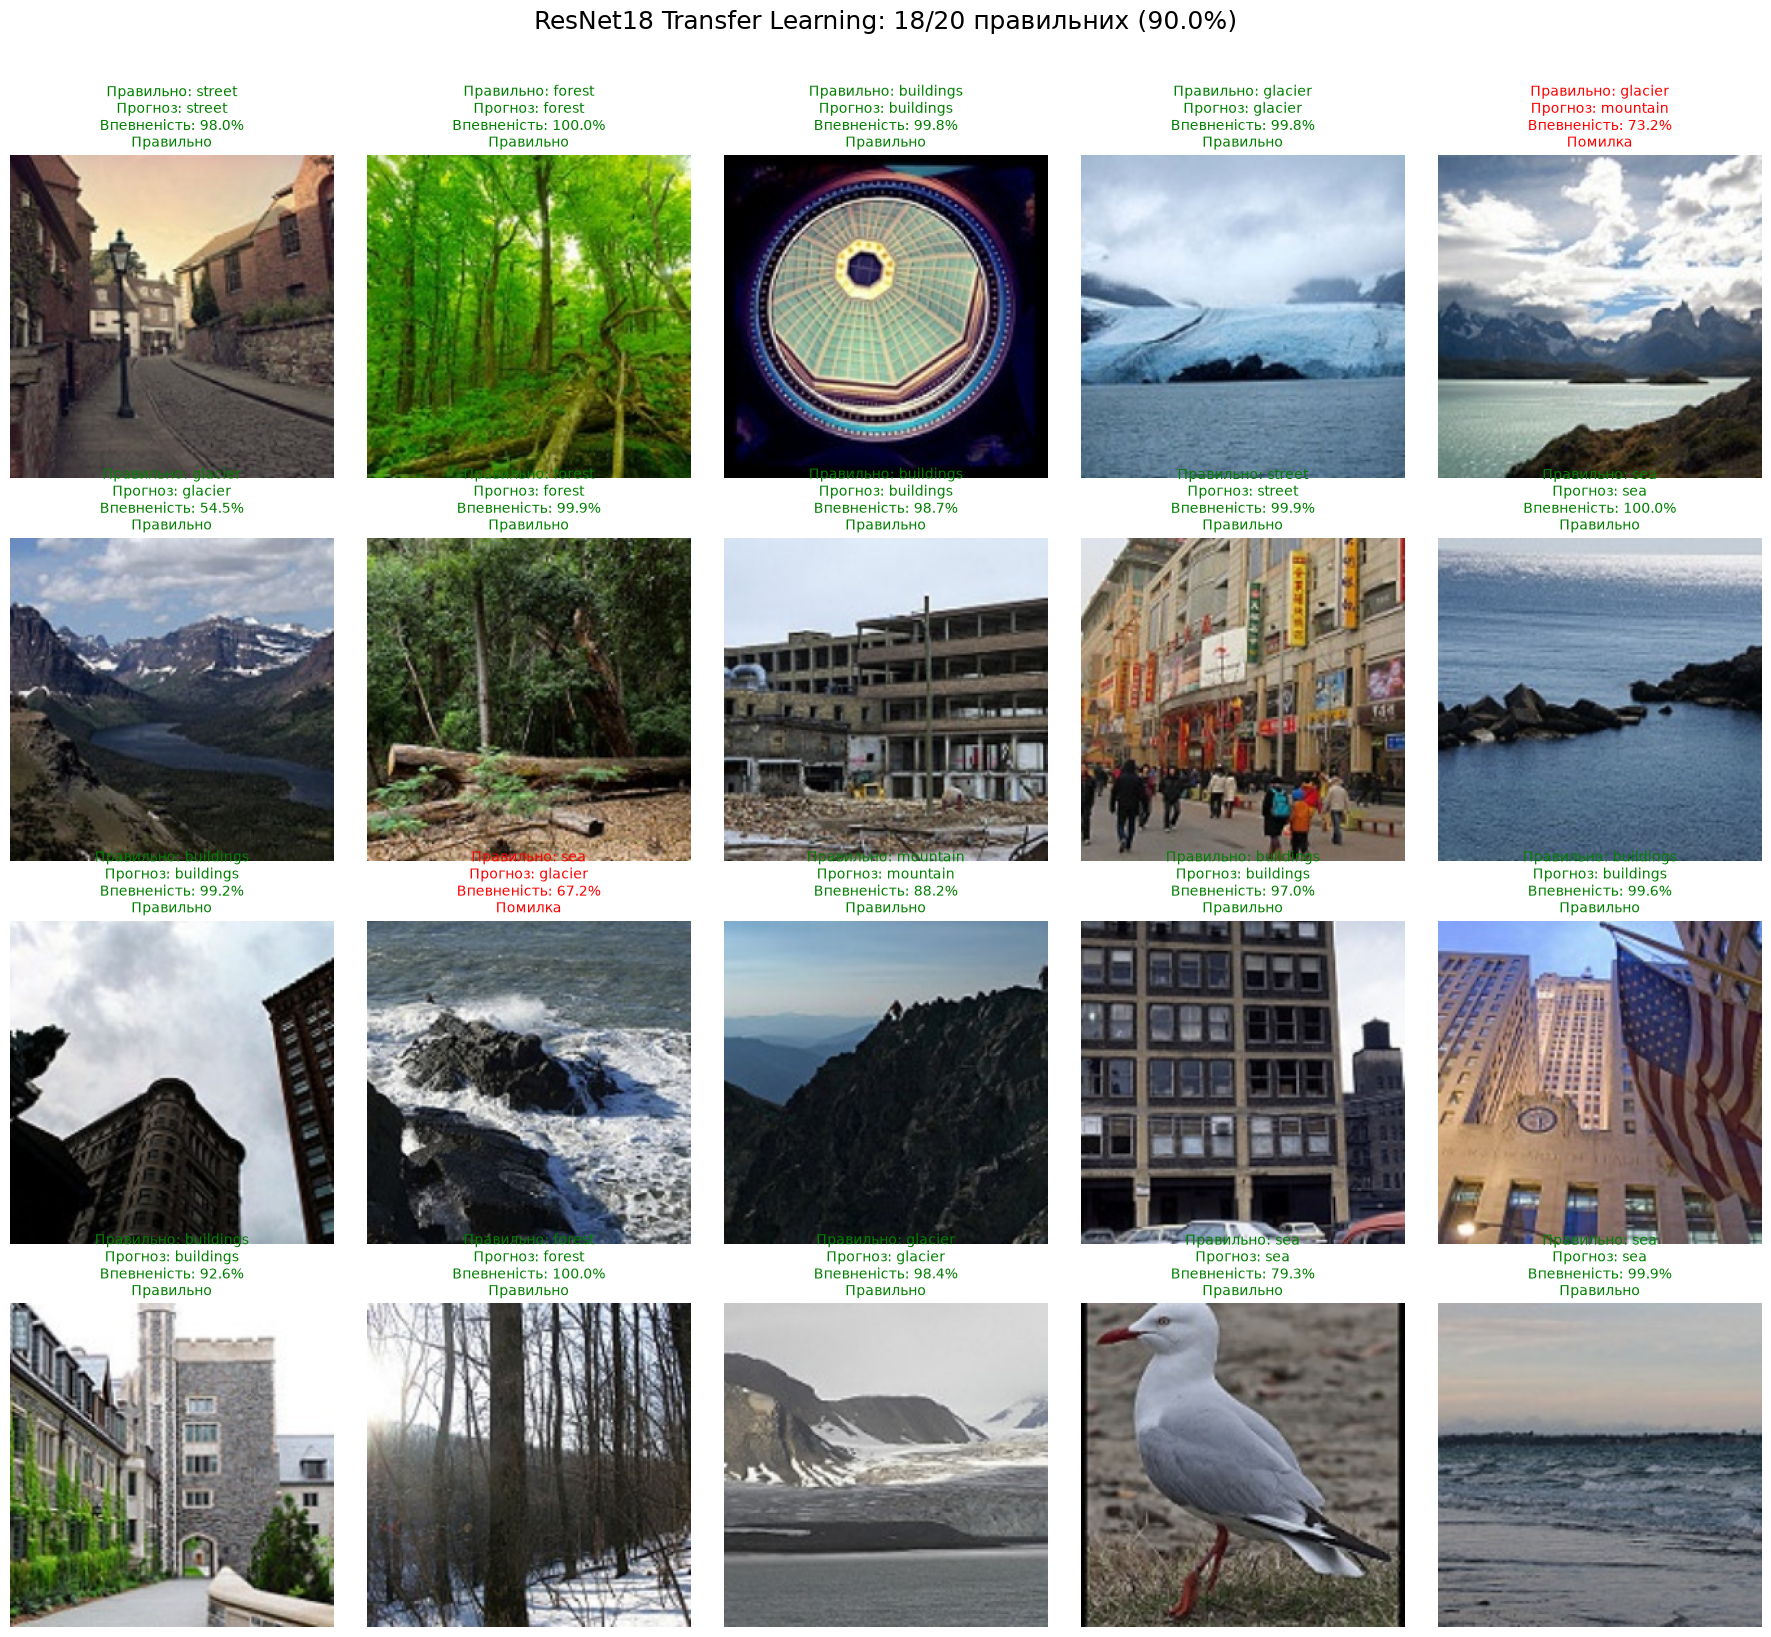

Правильних прогнозів: 18 із 20
Accuracy для вибраних зображень: 90.00%


In [73]:
resnet_model.load_state_dict(best_resnet_weights)
resnet_model.to(device)

show_resnet_predictions(
    model=resnet_model,
    dataset=resnet_test_dataset,
    class_names=resnet_class_names,
    device=device,
    num_images=20,
    seed=42
)

### Підсумки:

У роботі було реалізовано два підходи до класифікації природних сцен: власну згорткову нейронну мережу та Transfer Learning на основі попередньо навченої ResNet18. 

SimpleCNN досягла validation accuracy 82,15% і F1-macro 0,8232. ResNet18 показала значно кращий результат: validation accuracy 90,67%, F1-macro 0,9083 і F1-weighted 0,9063. Таким чином, використання Transfer Learning підвищило accuracy на 8,52 процентного пункта, а F1-macro — на 0,0851. Найкращі ваги ResNet18 було отримано на 9-й епосі та збережено за критерієм максимального validation F1-macro. 

Навчання виконувалося на GPU NVIDIA GeForce GTX 1070 Ti, що дозволило суттєво скоротити час обчислень. Отримані результати підтверджують, що попередньо навчена ResNet18 є ефективнішим рішенням для цього набору даних, ніж проста CNN, навчена з нуля.